In [7]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE  # for dimension reduction
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [2]:
embeddings = torch.load('all_fm-rna_embeddings_filtered.pt')

In [ ]:
# mean along sequence length
embeddings = [torch.mean(emb, dim=0).numpy() for emb in embeddings.values()]
embeddings = np.array(embeddings)

In [4]:
embeddings.shape

(10325, 640)

In [ ]:
# tsne = TSNE(n_components=2, random_state=42)
# reduced_embeddings = tsne.fit_transform(embeddings)
# print(reduced_embeddings.shape)

(2654, 2)


In [5]:
scaled_data = StandardScaler().fit_transform(embeddings)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
reduced_embeddings = reducer.fit_transform(scaled_data)

c:\Users\Julius\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


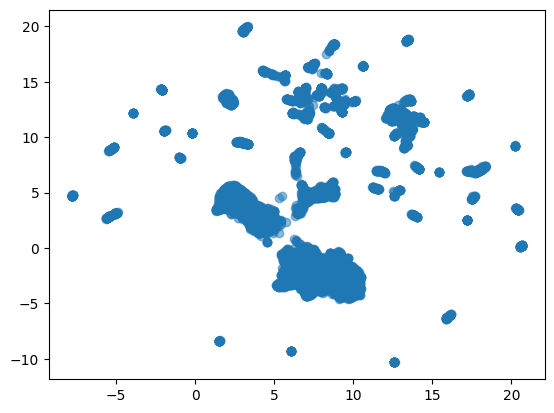

In [6]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=0.5)

In [8]:
df = pd.read_parquet('synthetic+real_dataset_filtered_numpeaks.parquet')

In [ ]:
arr_seqlength = np.array(df['length'])
arr_numpeaks = np.array(df['num_peaks'])

In [44]:
arr_fpts = np.array([arr_fpt.tolist() for arr_fpt in df['fpts']])

In [45]:
arr_fpts.shape

(10325, 1000)

In [52]:
arr_medlog10fpt = []

for i in range(arr_fpts.shape[0]):
    arr_medlog10fpt.append(np.median(np.log10(arr_fpts[i,:][arr_fpts[i,:] != 0])))

arr_medlog10fpt = np.array(arr_medlog10fpt)

In [53]:
print(np.min(arr_medlog10fpt), np.max(arr_medlog10fpt))

-0.725842165606983 7.868788930559656


In [54]:
arr_medlog10fpt.shape

(10325,)

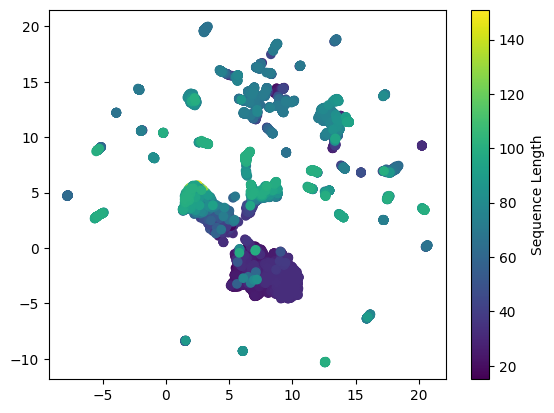

In [13]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=1,
            c=arr_seqlength, cmap='viridis')

plt.colorbar(label='Sequence Length')

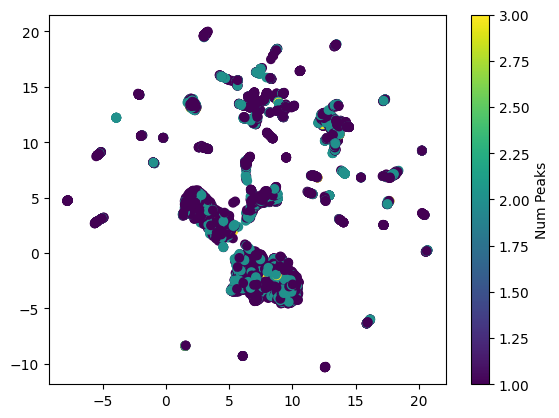

In [15]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=1,
            c=arr_numpeaks, cmap='viridis')

plt.colorbar(label='Num Peaks')

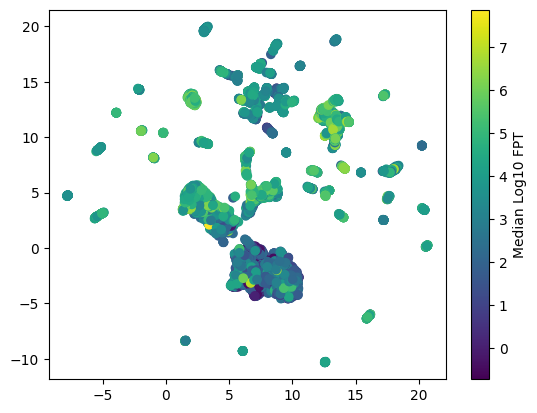

In [56]:
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=1,
            c=arr_medlog10fpt, cmap='viridis')

plt.colorbar(label='Median Log10 FPT')

In [60]:
arr_synth_or_nat = np.array([filepath is None for filepath in df['filepath']])

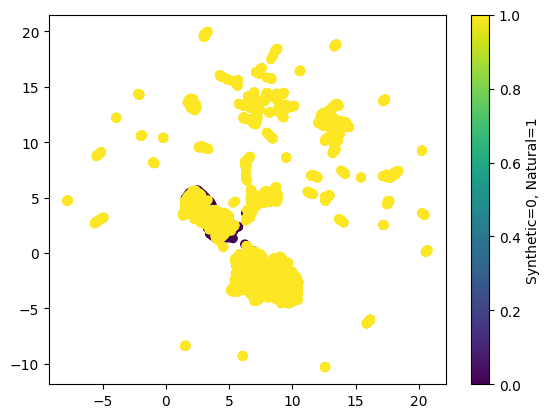

In [69]:
#%matplotlib tk
%matplotlib inline

plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], alpha=1,
            c=arr_synth_or_nat, cmap='viridis')

plt.colorbar(label='Synthetic=0, Natural=1')

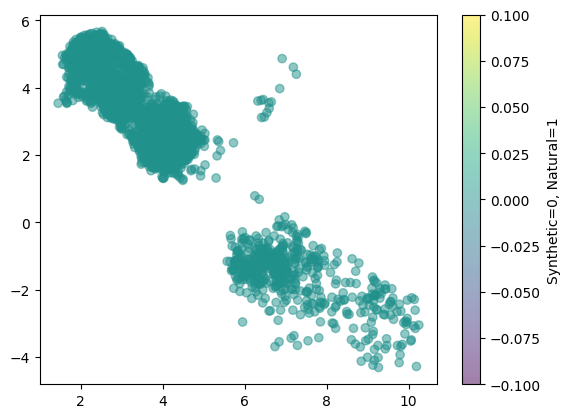

In [64]:
plt.scatter(reduced_embeddings[arr_synth_or_nat==0,0], reduced_embeddings[arr_synth_or_nat==0,1], alpha=0.5,
            c=arr_synth_or_nat[arr_synth_or_nat==0], cmap='viridis')

plt.colorbar(label='Synthetic=0, Natural=1')

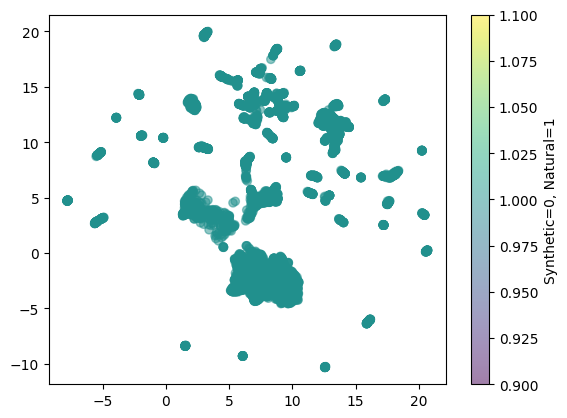

In [70]:
plt.scatter(reduced_embeddings[arr_synth_or_nat==1,0], reduced_embeddings[arr_synth_or_nat==1,1], alpha=0.5,
            c=arr_synth_or_nat[arr_synth_or_nat==1], cmap='viridis')

plt.colorbar(label='Synthetic=0, Natural=1')

(array([3.77069482, 0.        , 0.        , 0.        , 0.        ,
        1.18237518, 0.        , 0.        , 0.        , 0.04693   ]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

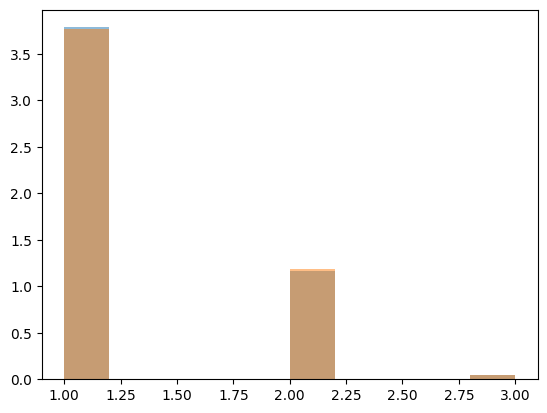

In [85]:
plt.hist(arr_numpeaks[arr_synth_or_nat==0], alpha=0.5, density=True)
plt.hist(arr_numpeaks[arr_synth_or_nat==1], alpha=0.5, density=True)

In [117]:
np.sum(arr_numpeaks==1) / np.sum(arr_numpeaks==2)

np.float64(3.2064993829699713)

In [87]:
arr_lengths = np.array(df['length'])

In [88]:
bin_edges_length = np.arange(np.min(arr_lengths), np.max(arr_lengths)+1)
hist_length, _ = np.histogram(arr_lengths, bins=bin_edges_length)

In [91]:
hist_length

array([ 27,  79, 132, 164, 203, 265, 274, 274, 271, 279, 155, 269, 266,
       287, 265, 260, 291, 291,  84,  67,  71,  89,  74,  71,  71,  66,
        57,  63,  67,  46,  55,  65,  78,  73,  63,  39,  48,  54,  41,
        49,  41,  47,  47,  62,  97,  84,  85, 151,  82,  80, 151, 186,
        99, 169, 198, 172, 235, 214, 216, 154, 137, 147,  86,  68, 201,
        76,  56, 118,  50,  60,  47,  52,  50,  48,  51,  41,  42,  59,
        67,  77,  88,  84,  69,  79,  89,  84,  17,  13,   9,  17,  17,
        11,   9,  14,  10,   5,   9,   7,   7,   8,   9,   8,   8,  13,
         4,   7,   6,   5,   4,   5,   4,   8,   6,   6,   2,   2,   3,
         2,   3,   3,   2,   3,   4,   2,   1,   2,   1,   2,   0,   0,
         2,   1,   3,   1,   0,   1])

In [92]:
idx = np.arange(len(arr_lengths))

In [93]:
idx

array([    0,     1,     2, ..., 10322, 10323, 10324])

In [ ]:
bucket_width = 15

bin_edges_length = np.arange(np.min(arr_lengths), np.max(arr_lengths)+1, bucket_width)
new_hist_length, _ = np.histogram(arr_lengths, bins=bin_edges_length)

In [95]:
new_hist_length

array([3210, 1668,  859, 2276, 1247,  835,  139,   66,   24])

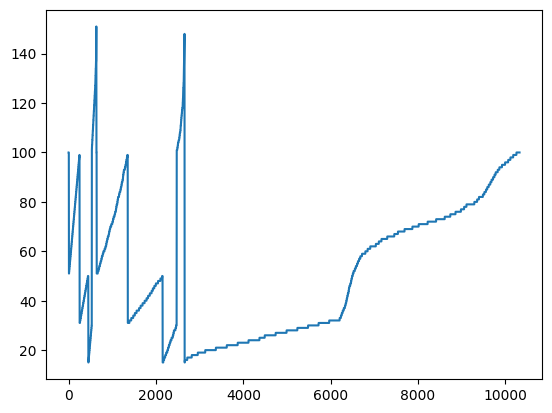

In [97]:
plt.plot(arr_lengths)

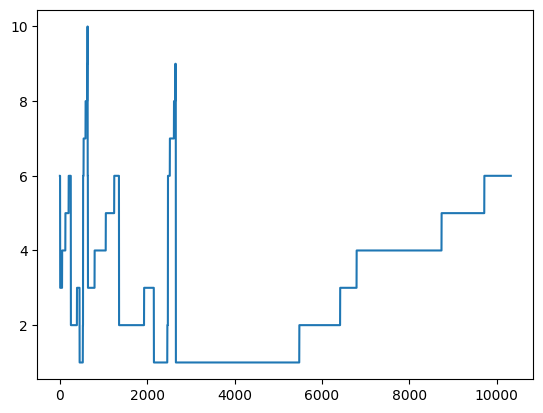

In [98]:
plt.plot(arr_lengths // bucket_width)

In [99]:
idx = idx[np.argsort(arr_lengths[idx] // bucket_width)]

In [101]:
batch_size = 32
batches = [idx[i:i+batch_size] for i in range(0, len(idx), batch_size)]

In [104]:
arr_lengths[batches[0]]

array([27, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 20, 27, 20, 20, 20, 20, 20, 20, 20])

In [111]:
arr_lengths[batches[250]]

array([71, 71, 71, 71, 70, 70, 70, 70, 70, 70, 70, 70, 70, 79, 79, 79, 79,
       79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79, 79])

In [108]:
len(batches)

323

In [112]:
(len(arr_lengths) + batch_size - 1) // batch_size

323